In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

TINTA, AZUL, NARANJA, VERDE, GRIS, FONDO = "#1d2433", "#2f6f9f", "#d1603d", "#4c8b5b", "#9aa3b2", "#fbfaf8"

mpl.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "savefig.facecolor": FONDO,
    "axes.edgecolor": TINTA, "axes.linewidth": 0.9, "axes.labelcolor": TINTA,
    "axes.titlesize": 13, "axes.titleweight": "semibold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA, "ytick.color": TINTA, "text.color": TINTA,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "font.family": "DejaVu Sans", "figure.dpi": 120, "savefig.dpi": 220,
    "grid.color": "#dfe3e8", "grid.linewidth": 0.8, "axes.grid": True,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 10,
})


def mco(x, y):
    """Estimadores de MCO en la regresion lineal simple, con las formulas de la hoja."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    xb, yb = x.mean(), y.mean() #Defines que xb, yb son xpromedio. ypromedio
    dx, dy = x - xb, y - yb

    Sxx, Syy, Sxy = dx @ dx, dy @ dy, dx @ dy

    b1 = Sxy / Sxx                 # beta_1 = Sxy / Sxx
    b0 = yb - b1 * xb              # beta_0 = ybar - beta_1 * xbar

    yhat = b0 + b1 * x
    u = y - yhat

    SSR = u @ u #SSR=Syy
    SSE = Syy - SSR #Debe de dar 0
    return dict(x=x, y=y, n=x.size, xb=xb, yb=yb, Sxx=Sxx, Syy=Syy, Sxy=Sxy,
                b0=b0, b1=b1, yhat=yhat, u=u, SST=Syy, SSE=SSE, SSR=SSR,
                R2=SSE / Syy, rho=Sxy / np.sqrt(Sxx * Syy))


def resumen(r, titulo=""):
    if titulo:
        print(titulo)
        print("=" * len(titulo))
    print(f"n = {r['n']:d}      x̄ = {r['xb']:.6g}      ȳ = {r['yb']:.6g}")
    print(f"Sxx = {r['Sxx']:.6g}    Syy = {r['Syy']:.6g}    Sxy = {r['Sxy']:.6g}")
    print(f"β̂1 = {r['b1']:.6f}     β̂0 = {r['b0']:.6f}")
    print(f"SCRmin = {r['SSR']:.6f}   SSE = {r['SSE']:.6f}   SST = {r['SST']:.6f}")
    print(f"R² = {r['R2']:.6f}    ρ̂xy = {r['rho']:.6f}")
    print(f"[ecuaciones normales]  Σûᵢ = {r['u'].sum():.2e}    Σxᵢûᵢ = {r['x'] @ r['u']:.2e}")

In [ ]:
x1 = np.array([2, 4, 6, 8, 10, 12], float)
y1 = np.array([3, 5, 6, 8, 7, 10], float)
r1 = mco(x1, y1)

print(f"{'i':>2} {'xᵢ':>5} {'yᵢ':>5} {'xᵢ-x̄':>7} {'yᵢ-ȳ':>7} {'producto':>9} {'(xᵢ-x̄)²':>9}")
for i, (xi, yi) in enumerate(zip(x1, y1), start=1):
    dx, dy = xi - r1["xb"], yi - r1["yb"]
    print(f"{i:>2} {xi:>5.0f} {yi:>5.0f} {dx:>7.1f} {dy:>7.1f} {dx*dy:>9.2f} {dx**2:>9.2f}")
print(f"{'Σ':>2} {'':>5} {'':>5} {'':>7} {'':>7} {r1['Sxy']:>9.2f} {r1['Sxx']:>9.2f}")
print()

resumen(r1, "Ejercicio 2.1")
print(f"\nSyy - Sxy²/Sxx = {r1['Syy'] - r1['Sxy']**2 / r1['Sxx']:.6f}   (coincide con SCRmin)")

 i    xᵢ    yᵢ   xᵢ-x̄    yᵢ-ȳ  producto  (xᵢ-x̄)²
 1     2     3    -5.0    -3.5     17.50     25.00
 2     4     5    -3.0    -1.5      4.50      9.00
 3     6     6    -1.0    -0.5      0.50      1.00
 4     8     8     1.0     1.5      1.50      1.00
 5    10     7     3.0     0.5      1.50      9.00
 6    12    10     5.0     3.5     17.50     25.00
 Σ                                 43.00     70.00

Ejercicio 2.1
n = 6      x̄ = 7      ȳ = 6.5
Sxx = 70    Syy = 29.5    Sxy = 43
β̂1 = 0.614286     β̂0 = 2.200000
SCRmin = 3.085714   SSE = 26.414286   SST = 29.500000
R² = 0.895400    ρ̂xy = 0.946256
[ecuaciones normales]  Σûᵢ = 3.55e-15    Σxᵢûᵢ = 2.49e-14

Syy - Sxy²/Sxx = 3.085714   (coincide con SCRmin)


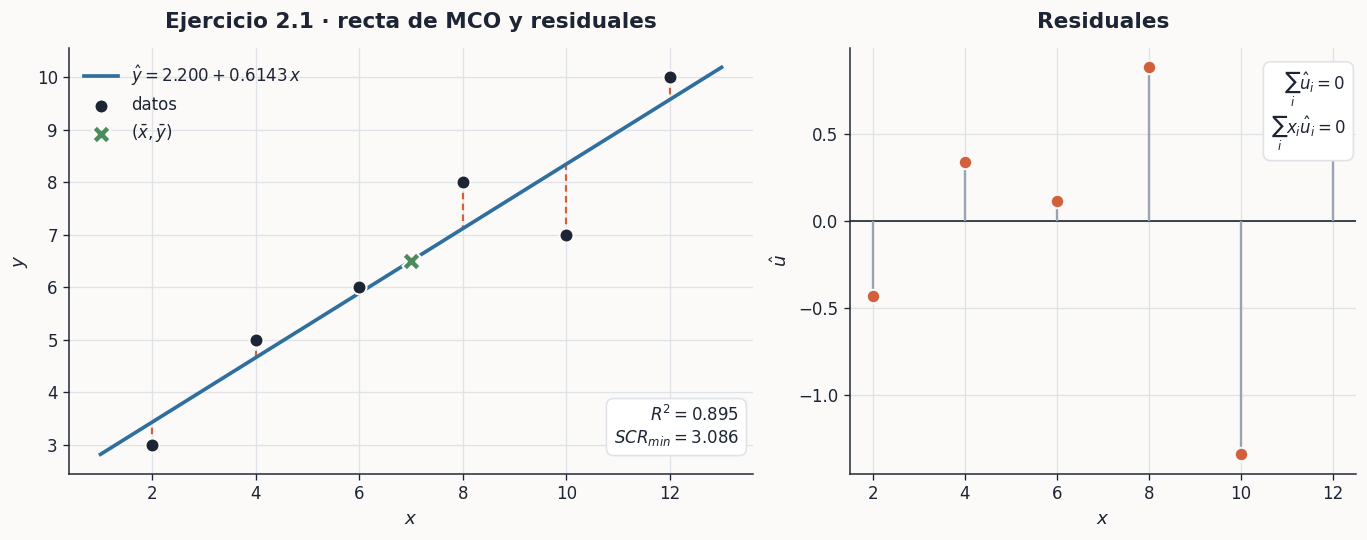

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})

gx = np.linspace(x1.min() - 1, x1.max() + 1, 200)
ax1.plot(gx, r1["b0"] + r1["b1"] * gx, color=AZUL, lw=2.2, zorder=2,
         label=f"$\\hat{{y}} = {r1['b0']:.3f} + {r1['b1']:.4f}\\,x$")
for xi, yi, yh in zip(x1, y1, r1["yhat"]):
    ax1.plot([xi, xi], [yi, yh], color=NARANJA, lw=1.3, ls=(0, (3, 2)), zorder=1)
ax1.scatter(x1, y1, s=70, color=TINTA, zorder=3, ec=FONDO, lw=1.2, label="datos")
ax1.scatter([r1["xb"]], [r1["yb"]], s=120, marker="X", color=VERDE, zorder=4, ec=FONDO, lw=1.2,
            label=r"$(\bar{x},\bar{y})$")
ax1.set(xlabel="$x$", ylabel="$y$", title="Ejercicio 2.1 · recta de MCO y residuales")
ax1.legend(loc="upper left")
ax1.text(0.98, 0.06, f"$R^2 = {r1['R2']:.3f}$\n$SCR_{{min}} = {r1['SSR']:.3f}$",
         transform=ax1.transAxes, ha="right", va="bottom", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#dfe3e8"))

ax2.axhline(0, color=TINTA, lw=1)
ax2.vlines(x1, 0, r1["u"], color=GRIS, lw=1.4)
ax2.scatter(x1, r1["u"], s=65, color=NARANJA, zorder=3, ec=FONDO, lw=1.2)
ax2.set(xlabel="$x$", ylabel=r"$\hat{u}$", title="Residuales")
ax2.text(0.98, 0.95, r"$\sum_i \hat{u}_i = 0$" + "\n" + r"$\sum_i x_i\hat{u}_i = 0$",
         transform=ax2.transAxes, ha="right", va="top", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#dfe3e8"))

fig.tight_layout()
plt.show()

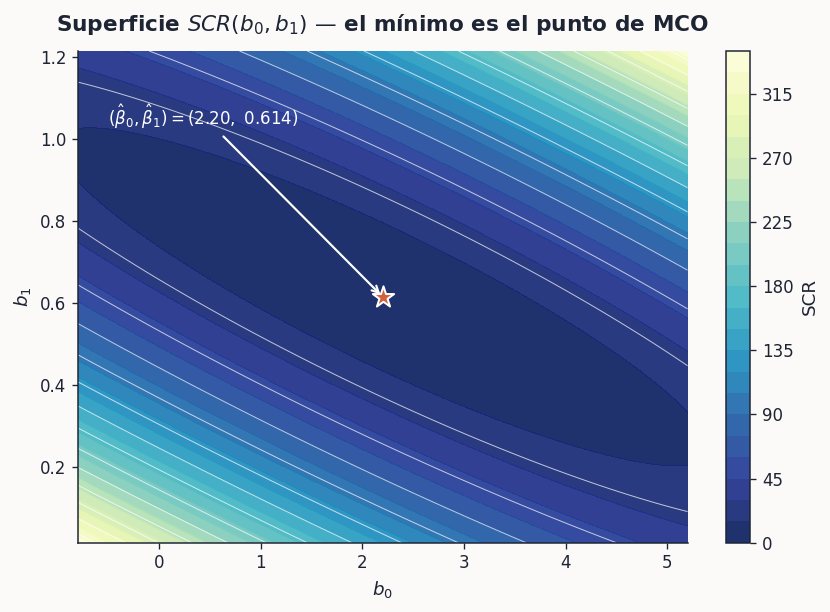

In [ ]:
b0g = np.linspace(r1["b0"] - 3, r1["b0"] + 3, 300)
b1g = np.linspace(r1["b1"] - 0.6, r1["b1"] + 0.6, 300)
B0, B1 = np.meshgrid(b0g, b1g)
SCR = ((y1[:, None, None] - B0[None] - B1[None] * x1[:, None, None]) ** 2).sum(axis=0)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
cf = ax.contourf(B0, B1, SCR, levels=28, cmap="YlGnBu_r", alpha=0.92)
ax.contour(B0, B1, SCR, levels=14, colors="white", linewidths=0.6, alpha=0.7)
ax.scatter([r1["b0"]], [r1["b1"]], s=180, marker="*", color=NARANJA, zorder=5, ec="white", lw=1.2)
ax.annotate(f"$(\\hat{{\\beta}}_0,\\hat{{\\beta}}_1) = ({r1['b0']:.2f},\\ {r1['b1']:.3f})$",
            xy=(r1["b0"], r1["b1"]), xytext=(r1["b0"] - 2.7, r1["b1"] + 0.42),
            fontsize=10, color="white", arrowprops=dict(arrowstyle="->", color="white", lw=1.3))
ax.set(xlabel="$b_0$", ylabel="$b_1$", title="Superficie $SCR(b_0,b_1)$ — el mínimo es el punto de MCO")
ax.grid(False)
fig.colorbar(cf, ax=ax, label="SCR")
fig.tight_layout()
plt.show()

Muestra original
n = 5      x̄ = 3      ȳ = 4
Sxx = 10    Syy = 10    Sxy = 9
β̂1 = 0.900000     β̂0 = 1.300000
SCRmin = 1.900000   SSE = 8.100000   SST = 10.000000
R² = 0.810000    ρ̂xy = 0.900000
[ecuaciones normales]  Σûᵢ = 4.44e-16    Σxᵢûᵢ = 4.44e-16

Con dato atipico (5, 20)
n = 5      x̄ = 3      ȳ = 6.8
Sxx = 10    Syy = 222.8    Sxy = 37
β̂1 = 3.700000     β̂0 = -4.300000
SCRmin = 85.900000   SSE = 136.900000   SST = 222.800000
R² = 0.614452    ρ̂xy = 0.783870
[ecuaciones normales]  Σûᵢ = 3.55e-15    Σxᵢûᵢ = 7.11e-15

Cambio en la pendiente:  0.90 → 3.70  (×4.11)
Cambio en el intercepto: 1.30 → -4.30


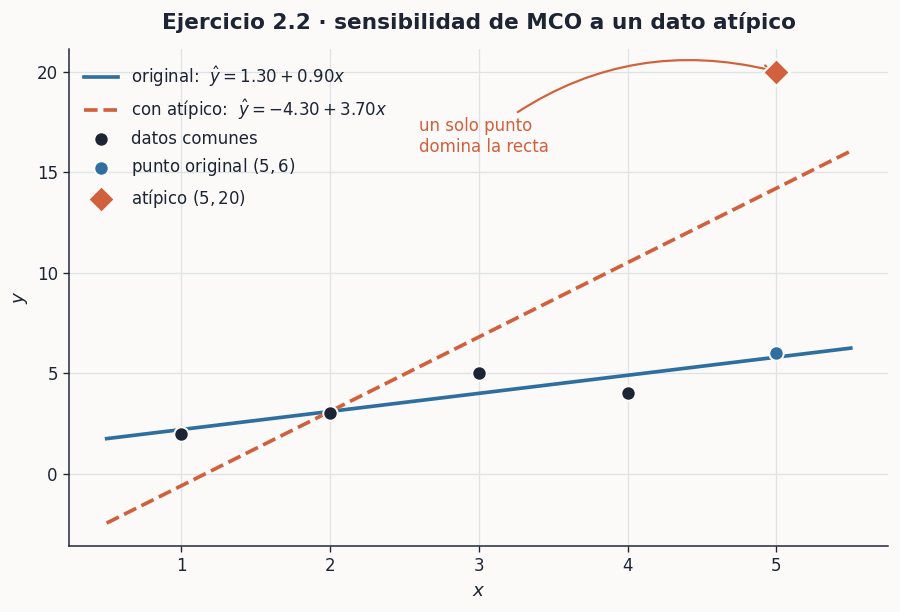

In [ ]:
x2 = np.array([1, 2, 3, 4, 5], float)
y_or = np.array([2, 3, 5, 4, 6], float)
y_at = np.array([2, 3, 5, 4, 20], float)          # ultimo punto reemplazado por (5, 20)

r_or, r_at = mco(x2, y_or), mco(x2, y_at)
resumen(r_or, "Muestra original")
print()
resumen(r_at, "Con dato atipico (5, 20)")
print(f"\nCambio en la pendiente:  {r_or['b1']:.2f} → {r_at['b1']:.2f}  (×{r_at['b1']/r_or['b1']:.2f})")
print(f"Cambio en el intercepto: {r_or['b0']:.2f} → {r_at['b0']:.2f}")

fig, ax = plt.subplots(figsize=(7.6, 5.2))
gx = np.linspace(0.5, 5.5, 200)

ax.plot(gx, r_or["b0"] + r_or["b1"] * gx, color=AZUL, lw=2.2,
        label=f"original:  $\\hat{{y}} = {r_or['b0']:.2f} + {r_or['b1']:.2f}x$")
ax.plot(gx, r_at["b0"] + r_at["b1"] * gx, color=NARANJA, lw=2.2, ls="--",
        label=f"con atípico:  $\\hat{{y}} = {r_at['b0']:.2f} + {r_at['b1']:.2f}x$")

ax.scatter(x2[:4], y_or[:4], s=75, color=TINTA, zorder=3, ec=FONDO, lw=1.2, label="datos comunes")
ax.scatter([5], [6], s=75, color=AZUL, zorder=3, ec=FONDO, lw=1.2, label="punto original $(5,6)$")
ax.scatter([5], [20], s=130, color=NARANJA, zorder=4, ec=FONDO, lw=1.4, marker="D",
           label="atípico $(5,20)$")
ax.annotate("un solo punto\ndomina la recta", xy=(5, 20), xytext=(2.6, 16), fontsize=10, color=NARANJA,
            arrowprops=dict(arrowstyle="->", color=NARANJA, lw=1.3, connectionstyle="arc3,rad=-0.25"))

ax.set(xlabel="$x$", ylabel="$y$", title="Ejercicio 2.2 · sensibilidad de MCO a un dato atípico")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

β̂1  = Sxy/Sxx        = 54.0/36.0 = 1.5
β̂0  = ȳ - β̂1·x̄       = 45.0 - 1.5·12.0 = 27.0
ρ̂xy = Sxy/√(Sxx·Syy) = 54.0/60 = 0.9
R²  = ρ̂xy²           = 0.81

SSE = 81   SSR = 19   SST = 100
El regresor explica el 81% de la variación muestral de y.


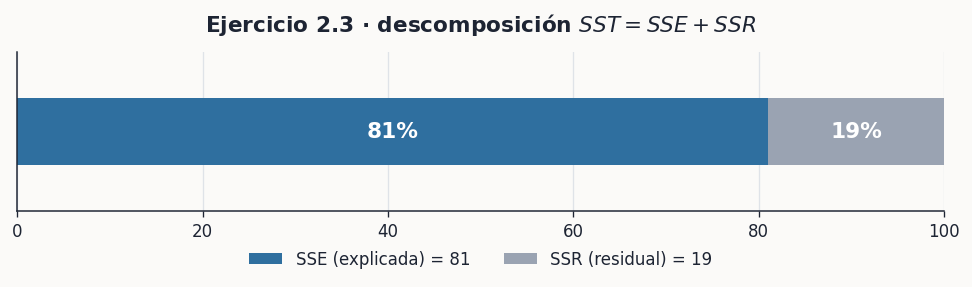

In [ ]:
Sxy, Sxx, Syy, xb, yb, n = 54.0, 36.0, 100.0, 12.0, 45.0, 8

b1 = Sxy / Sxx
b0 = yb - b1 * xb
rho = Sxy / np.sqrt(Sxx * Syy)
R2 = rho ** 2
SSE, SSR = R2 * Syy, Syy - R2 * Syy

print(f"β̂1  = Sxy/Sxx        = {Sxy}/{Sxx} = {b1}")
print(f"β̂0  = ȳ - β̂1·x̄       = {yb} - {b1}·{xb} = {b0}")
print(f"ρ̂xy = Sxy/√(Sxx·Syy) = {Sxy}/{np.sqrt(Sxx*Syy):.0f} = {rho}")
print(f"R²  = ρ̂xy²           = {R2}")
print(f"\nSSE = {SSE:.0f}   SSR = {SSR:.0f}   SST = {Syy:.0f}")
print(f"El regresor explica el {R2:.0%} de la variación muestral de y.")

fig, ax = plt.subplots(figsize=(8.2, 2.9))
ax.barh([0], [SSE], color=AZUL, height=0.5, label=f"SSE (explicada) = {SSE:.0f}")
ax.barh([0], [SSR], left=[SSE], color=GRIS, height=0.5, label=f"SSR (residual) = {SSR:.0f}")
ax.text(SSE / 2, 0, f"{R2:.0%}", ha="center", va="center", color="white", fontsize=13, fontweight="bold")
ax.text(SSE + SSR / 2, 0, f"{1 - R2:.0%}", ha="center", va="center", color="white",
        fontsize=13, fontweight="bold")
ax.set(xlim=(0, Syy), ylim=(-0.6, 0.6), yticks=[],
       title="Ejercicio 2.3 · descomposición $SST = SSE + SSR$")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), ncol=2)
fig.tight_layout()
plt.show()

β̂ = Sxy/Sxx = 0.0056/0.008 = 0.7000
α̂ = ȳ - β̂·x̄ = 0.012 - 0.70·0.01 = 0.0050  (0.50% mensual)

β̂ = 0.70 < 1  →  el activo es menos volátil que el mercado:
   +1% en el exceso de mercado ≈ +0.70% en el exceso del activo.
α̂ > 0  →  0.50% mensual no explicado por el riesgo de mercado.
   Conclusión firme requiere prueba de hipótesis sobre α̂, no sólo su signo.

verificación → Sxx = 0.008000, Sxy = 0.005600, β̂ = 0.7000, α̂ = 0.0050


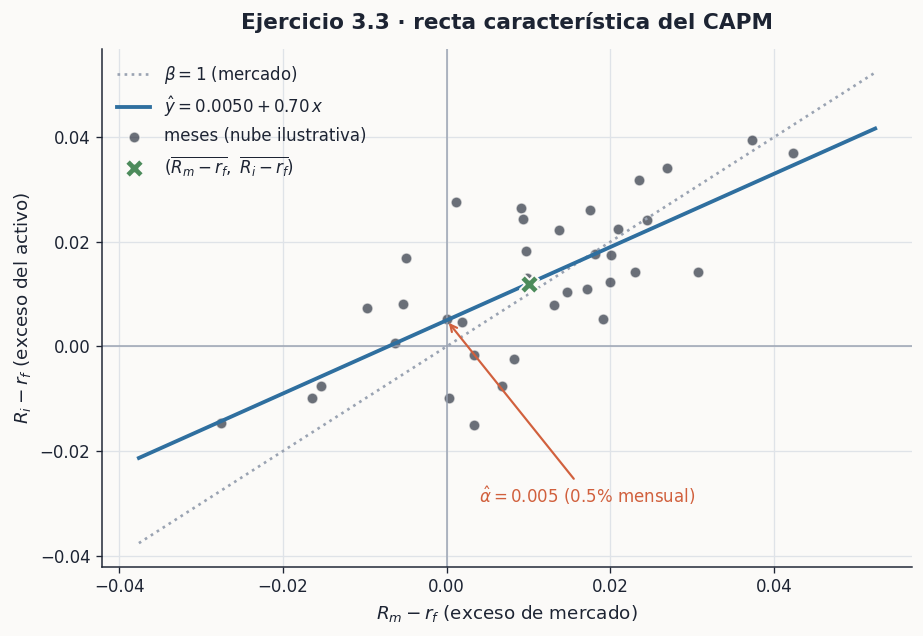

In [ ]:
Sxy_c, Sxx_c, ybar_c, xbar_c = 0.0056, 0.0080, 0.012, 0.010

beta = Sxy_c / Sxx_c
alpha = ybar_c - beta * xbar_c

print(f"β̂ = Sxy/Sxx = {Sxy_c}/{Sxx_c} = {beta:.4f}")
print(f"α̂ = ȳ - β̂·x̄ = {ybar_c} - {beta:.2f}·{xbar_c} = {alpha:.4f}  ({alpha:.2%} mensual)")
print()
print(f"β̂ = {beta:.2f} < 1  →  el activo es menos volátil que el mercado:")
print(f"   +1% en el exceso de mercado ≈ +{beta:.2f}% en el exceso del activo.")
print(f"α̂ > 0  →  {alpha:.2%} mensual no explicado por el riesgo de mercado.")
print("   Conclusión firme requiere prueba de hipótesis sobre α̂, no sólo su signo.")

# nube ilustrativa construida para reproducir exactamente x̄, ȳ, Sxx y Sxy del enunciado
rng = np.random.default_rng(7)
m = 36
z = rng.normal(size=m); z -= z.mean(); z = z / np.sqrt(z @ z) * np.sqrt(Sxx_c)
xc = xbar_c + z

e = rng.normal(size=m); e -= e.mean()
e = e - (e @ z) / (z @ z) * z                      # ortogonal a x  =>  no altera Sxy
e = e / np.sqrt(e @ e) * np.sqrt(0.9 * Sxx_c * beta ** 2)
yc = alpha + beta * xc + e

chk = mco(xc, yc)
print(f"\nverificación → Sxx = {chk['Sxx']:.6f}, Sxy = {chk['Sxy']:.6f}, "
      f"β̂ = {chk['b1']:.4f}, α̂ = {chk['b0']:.4f}")

fig, ax = plt.subplots(figsize=(7.8, 5.4))
gx = np.linspace(xc.min() - 0.01, xc.max() + 0.01, 200)
ax.axhline(0, color=GRIS, lw=0.9)
ax.axvline(0, color=GRIS, lw=0.9)
ax.plot(gx, gx, color=GRIS, lw=1.6, ls=":", label=r"$\beta = 1$ (mercado)")
ax.plot(gx, alpha + beta * gx, color=AZUL, lw=2.3,
        label=f"$\\hat{{y}} = {alpha:.4f} + {beta:.2f}\\,x$")
ax.scatter(xc, yc, s=42, color=TINTA, alpha=0.65, ec=FONDO, lw=0.8, label="meses (nube ilustrativa)")
ax.scatter([xbar_c], [ybar_c], s=130, marker="X", color=VERDE, zorder=5, ec=FONDO, lw=1.2,
           label=r"$(\overline{R_m-r_f},\ \overline{R_i-r_f})$")
ax.annotate(f"$\\hat{{\\alpha}} = {alpha:.3f}$ ({alpha:.1%} mensual)", xy=(0, alpha),
            xytext=(0.004, alpha - 0.035), fontsize=10, color=NARANJA,
            arrowprops=dict(arrowstyle="->", color=NARANJA, lw=1.3))
ax.set(xlabel="$R_m - r_f$ (exceso de mercado)", ylabel="$R_i - r_f$ (exceso del activo)",
       title="Ejercicio 3.3 · recta característica del CAPM")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

In [ ]:
a, b, c = 3.0, 100.0, 1000.0        # p. ej. decimales -> puntos porcentuales, pesos -> miles
rp = mco(a + b * x1, c * y1)

print(f"β̂1' obtenido = {rp['b1']:.10g}      (c/b)·β̂1 = {(c/b) * r1['b1']:.10g}")
print(f"β̂0' obtenido = {rp['b0']:.10g}   c·β̂0 - (ac/b)·β̂1 = {c*r1['b0'] - a*c/b*r1['b1']:.10g}")
print(f"β̂0' = c·β̂0 - a·β̂1' = {c*r1['b0'] - a*rp['b1']:.10g}")
print(f"\nR² original = {r1['R2']:.10g}   R² reescalado = {rp['R2']:.10g}  → invariante")

print("\nEjercicio 1.5:")
print(f"  Σûᵢ   = {r1['u'].sum():.2e}")
print(f"  Σxᵢûᵢ = {x1 @ r1['u']:.2e}")
print(f"  Σûᵢŷᵢ = {r1['u'] @ r1['yhat']:.2e}   → residuales ⊥ valores ajustados")

print("\nEjercicio 3.1:")
print(f"  SSE = {r1['SSE']:.6f}   Sxy²/Sxx = {r1['Sxy']**2 / r1['Sxx']:.6f}")
print(f"  SSE + SSR = {r1['SSE'] + r1['SSR']:.6f}  = SST = {r1['SST']:.6f} ✓")
print(f"  R² = {r1['R2']:.6f}   ρ̂xy² = {r1['rho']**2:.6f} ✓")

print("\nEjercicio 3.2:")
b_yx, b_xy = r1["Sxy"] / r1["Sxx"], r1["Sxy"] / r1["Syy"]
print(f"  β̂y|x = {b_yx:.6f}   β̂x|y = {b_xy:.6f}")
print(f"  producto = {b_yx * b_xy:.6f}   ρ̂xy² = {r1['rho']**2:.6f} ≤ 1 ✓")
print(f"  1/β̂y|x = {1/b_yx:.6f} ≠ β̂x|y  → son dos rectas distintas")

β̂1' obtenido = 6.142857143      (c/b)·β̂1 = 6.142857143
β̂0' obtenido = 2181.571429   c·β̂0 - (ac/b)·β̂1 = 2181.571429
β̂0' = c·β̂0 - a·β̂1' = 2181.571429

R² original = 0.8953995157   R² reescalado = 0.8953995157  → invariante

Ejercicio 1.5:
  Σûᵢ   = 3.55e-15
  Σxᵢûᵢ = 2.49e-14
  Σûᵢŷᵢ = 2.40e-14   → residuales ⊥ valores ajustados

Ejercicio 3.1:
  SSE = 26.414286   Sxy²/Sxx = 26.414286
  SSE + SSR = 29.500000  = SST = 29.500000 ✓
  R² = 0.895400   ρ̂xy² = 0.895400 ✓

Ejercicio 3.2:
  β̂y|x = 0.614286   β̂x|y = 1.457627
  producto = 0.895400   ρ̂xy² = 0.895400 ≤ 1 ✓
  1/β̂y|x = 1.627907 ≠ β̂x|y  → son dos rectas distintas


β̂0 = 10.076530     ȳ0 = 10.076530
β̂1 = 3.569788     ȳ1 - ȳ0 = 3.569788


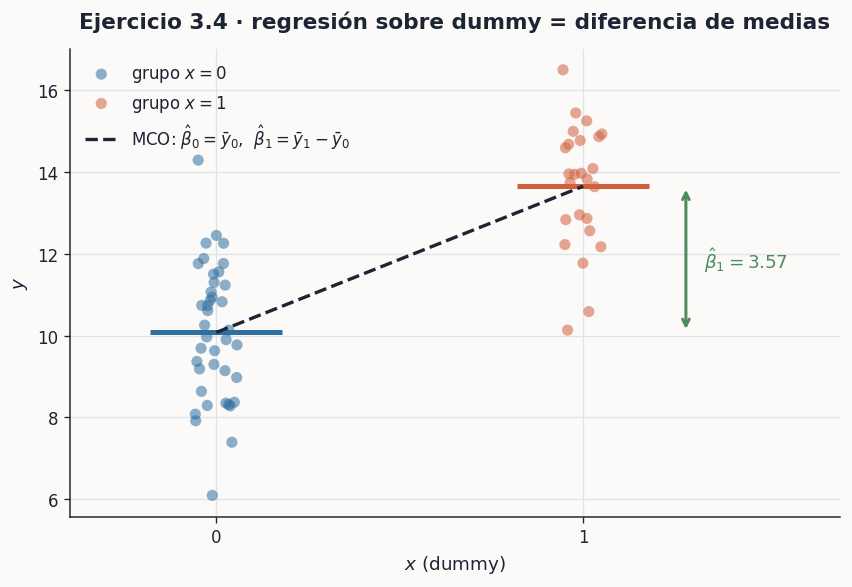

In [ ]:
rng = np.random.default_rng(42)
g0 = rng.normal(10.0, 2.0, 40)      # grupo x = 0
g1 = rng.normal(13.5, 2.0, 25)      # grupo x = 1

xd = np.r_[np.zeros(g0.size), np.ones(g1.size)]
yd = np.r_[g0, g1]
rd = mco(xd, yd)

print(f"β̂0 = {rd['b0']:.6f}     ȳ0 = {g0.mean():.6f}")
print(f"β̂1 = {rd['b1']:.6f}     ȳ1 - ȳ0 = {g1.mean() - g0.mean():.6f}")

fig, ax = plt.subplots(figsize=(7.2, 5.0))
for xv, g, col, lab in [(0, g0, AZUL, "grupo $x=0$"), (1, g1, NARANJA, "grupo $x=1$")]:
    ax.scatter(xv + rng.uniform(-0.06, 0.06, g.size), g, s=45, color=col, alpha=0.55,
               ec="none", label=lab)
    ax.hlines(g.mean(), xv - 0.18, xv + 0.18, color=col, lw=3)
ax.plot([0, 1], [g0.mean(), g1.mean()], color=TINTA, lw=2, ls="--",
        label=r"MCO: $\hat{\beta}_0=\bar{y}_0$,  $\hat{\beta}_1=\bar{y}_1-\bar{y}_0$")
ax.annotate("", xy=(1.28, g1.mean()), xytext=(1.28, g0.mean()),
            arrowprops=dict(arrowstyle="<->", color=VERDE, lw=1.8))
ax.text(1.33, (g0.mean() + g1.mean()) / 2, f"$\\hat{{\\beta}}_1 = {rd['b1']:.2f}$",
        color=VERDE, fontsize=11, va="center")
ax.set(xticks=[0, 1], xlim=(-0.4, 1.7), xlabel="$x$ (dummy)", ylabel="$y$",
       title="Ejercicio 3.4 · regresión sobre dummy = diferencia de medias")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

restricciones MCO:  Σc = 0.00e+00   Σc·x = 1.000000
restricciones alt:  Σc = 0.00e+00   Σc·x = 1.000000

Σc²  MCO = 0.023810  = 1/Sxx        = 0.023810
Σc²  alt = 0.047619  = 1/Sxx + Σd² = 0.047619
Σd² = 0.023810 > 0  →  MCO tiene varianza estrictamente menor

MCO:  media = 0.5010   var = 0.02385   teórica = 0.02381
Alt:  media = 0.5003   var = 0.04767   teórica = 0.04762


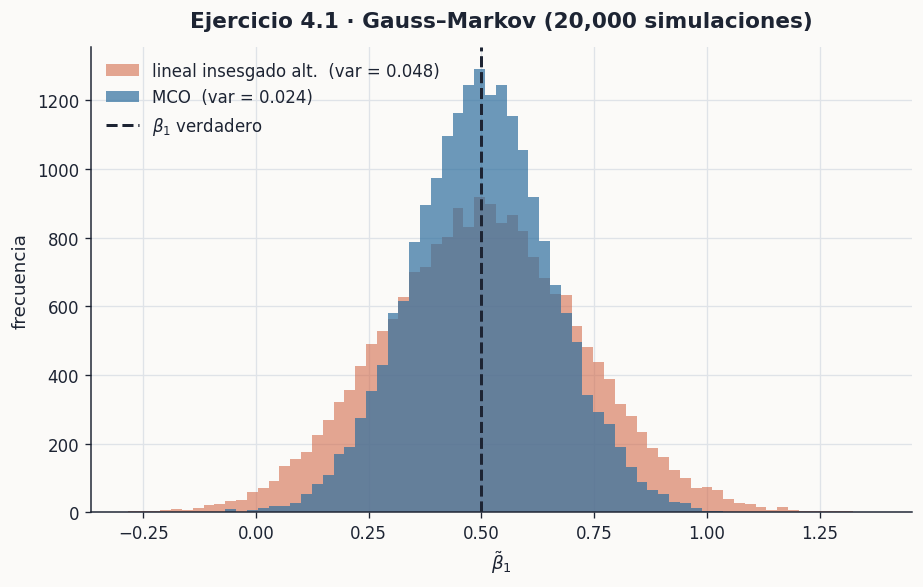

In [ ]:
xg = np.array([1, 2, 3, 4, 5, 6, 7, 8], float)
dxg = xg - xg.mean()
Sxxg = dxg @ dxg

c_mco = dxg / Sxxg                                   # pesos de MCO

d = np.array([1, -1, 0.5, -0.5, -1, 1, 0.5, -0.5])   # perturbacion arbitraria
d = d - d.mean()                                     # fuerza  sum(d_i) = 0
d = d - (d @ dxg) / Sxxg * dxg                       # fuerza  sum(d_i (x_i - xbar)) = 0
d = d / np.sqrt(d @ d) * np.sqrt(1 / Sxxg)           # escala moderada, solo para el contraste
c_alt = c_mco + d                                    # competidor lineal insesgado

print(f"restricciones MCO:  Σc = {c_mco.sum():.2e}   Σc·x = {c_mco @ xg:.6f}")
print(f"restricciones alt:  Σc = {c_alt.sum():.2e}   Σc·x = {c_alt @ xg:.6f}")
print(f"\nΣc²  MCO = {c_mco @ c_mco:.6f}  = 1/Sxx        = {1/Sxxg:.6f}")
print(f"Σc²  alt = {c_alt @ c_alt:.6f}  = 1/Sxx + Σd² = {1/Sxxg + d @ d:.6f}")
print(f"Σd² = {d @ d:.6f} > 0  →  MCO tiene varianza estrictamente menor")

rng = np.random.default_rng(2026)
B0v, B1v, sigma, R = 1.0, 0.5, 1.0, 20_000

U = rng.normal(0.0, sigma, size=(R, xg.size))
Y = B0v + B1v * xg + U                # cada renglon es una muestra distinta

b_mco = Y @ c_mco
b_alt = Y @ c_alt

print(f"\nMCO:  media = {b_mco.mean():.4f}   var = {b_mco.var():.5f}   teórica = {sigma**2 * (c_mco @ c_mco):.5f}")
print(f"Alt:  media = {b_alt.mean():.4f}   var = {b_alt.var():.5f}   teórica = {sigma**2 * (c_alt @ c_alt):.5f}")

fig, ax = plt.subplots(figsize=(7.8, 5.0))
bins = np.linspace(min(b_mco.min(), b_alt.min()), max(b_mco.max(), b_alt.max()), 70)
ax.hist(b_alt, bins=bins, color=NARANJA, alpha=0.55, label=f"lineal insesgado alt.  (var = {b_alt.var():.3f})")
ax.hist(b_mco, bins=bins, color=AZUL, alpha=0.70, label=f"MCO  (var = {b_mco.var():.3f})")
ax.axvline(B1v, color=TINTA, lw=1.8, ls="--", label=r"$\beta_1$ verdadero")
ax.set(xlabel=r"$\tilde{\beta}_1$", ylabel="frecuencia",
       title=f"Ejercicio 4.1 · Gauss–Markov ({R:,} simulaciones)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()